# MA-SpecFormer Reconstruction Benchmark

This notebook visualizes the reconstruction quality of the trained MA-SpecFormer model by comparing original spectra with their reconstructed counterparts from the test (validation) split.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from model.ma_specformer import MASpecFormer
from data.datamodule import MASpectrumDataModule

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load Checkpoint and Data

In [5]:
checkpoint_path = "/home/yacheng/ssl_outthere/encoder_spectrum/ma_specformer/outputs/dja_prism_f100lp_20260228_151905/last.ckpt"

print(f"Loading checkpoint: {checkpoint_path}")

# Load model from checkpoint
model = MASpecFormer.load_from_checkpoint(checkpoint_path, map_location=device)
model.eval()
model.to(device)
print(f"Model loaded with {sum(p.numel() for p in model.parameters()):,} parameters")

Loading checkpoint: /home/yacheng/ssl_outthere/encoder_spectrum/ma_specformer/outputs/jda_prism_f100lp_20260228_151905/last.ckpt
Model loaded with 1,620,354 parameters


In [6]:
# Load the data module (same configuration as training)
h5_path = "/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f150w.h5"

data_module = MASpectrumDataModule(
    h5_path=h5_path,
    batch_size=32,
    num_workers=0,
    train_val_split=0.9,
    min_snr=20.0,
)

# Setup the data
data_module.setup()

# Get test/validation dataloader
test_loader = data_module.test_dataloader()
print(f"Test set size: {len(data_module.val_dataset)} samples")

FileNotFoundError: HDF5 file not found: /u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f150w.h5

## Reconstruction Function

Define a function to perform masked reconstruction and visualize the results.

In [ ]:
def normalize_flux(flux, valid_mask, min_std=0.1):
    """Normalize flux per-sample using valid positions only."""
    B, T = flux.shape
    
    # Compute mean and std using only valid positions
    valid_flux = flux.clone()
    valid_flux[~valid_mask] = 0.0
    
    valid_count = valid_mask.sum(dim=1, keepdim=True).float().clamp(min=1)
    mean = valid_flux.sum(dim=1, keepdim=True) / valid_count
    
    sq_diff = ((flux - mean) ** 2) * valid_mask.float()
    var = sq_diff.sum(dim=1, keepdim=True) / valid_count
    std = var.sqrt().clamp(min=min_std)
    
    normalized_flux = (flux - mean) / std
    normalized_flux = normalized_flux * valid_mask.float()
    
    return normalized_flux, mean, std


@torch.no_grad()
def reconstruct_batch(model, batch):
    """
    Reconstruct a batch of spectra (no random masking, autoencoder-style).
    
    Only invalid positions are masked via valid_mask (same as model training).
    Tests the model's reconstruction ability on complete spectra.
    """
    flux = batch["flux"].to(device)
    wavelength = batch["wavelength"].to(device)
    valid_mask = batch["valid_mask"].to(device)
    
    # Normalize flux per-sample using valid positions only
    flux_norm, mean, std = normalize_flux(flux, valid_mask)
    
    # Prepare stats tensor for encode
    stats = torch.cat([mean, std], dim=-1)  # (B, 2)
    
    # Forward pass: full spectrum (no random masking)
    embeddings = model.encode(flux_norm, wavelength, valid_mask, stats=stats)
    reconstructions = model.head(embeddings[:, 1:, :]).squeeze(-1)  # Skip CLS token
    
    return {
        "original": flux.cpu().numpy(),
        "original_norm": flux_norm.cpu().numpy(),
        "reconstruction": reconstructions.cpu().numpy(),
        "wavelength": wavelength.cpu().numpy(),
        "valid_mask": valid_mask.cpu().numpy(),
        "mean": mean.cpu().numpy(),
        "std": std.cpu().numpy(),
    }

## Visualize Reconstruction Examples

Get a batch from the test set and visualize several reconstruction examples.

In [ ]:
# Get one batch from test set
test_batch = next(iter(test_loader))

# Perform reconstruction (autoencoder-style, no random masking)
results = reconstruct_batch(model, test_batch)

print(f"Batch shape: {results['original'].shape}")
print(f"Wavelength range: {results['wavelength'].min():.1f} - {results['wavelength'].max():.1f} Angstrom")

Batch shape: (32, 99)
Wavelength range: 12819.2 - 17193.4 Angstrom


In [ ]:
def plot_reconstruction_comparison(results, sample_indices, figsize=(14, 4)):
    """Plot original vs reconstructed spectra for given sample indices."""
    n_samples = len(sample_indices)
    fig, axes = plt.subplots(n_samples, 1, figsize=(figsize[0], figsize[1] * n_samples))
    
    if n_samples == 1:
        axes = [axes]
    
    for ax, idx in zip(axes, sample_indices):
        wavelength = results["wavelength"][idx]
        original = results["original_norm"][idx]
        reconstruction = results["reconstruction"][idx]
        valid_mask = results["valid_mask"][idx].astype(bool)
        
        # Plot only valid positions
        wl_valid = wavelength[valid_mask]
        orig_valid = original[valid_mask]
        recon_valid = reconstruction[valid_mask]
        
        # Sort by wavelength for proper line plot
        sort_idx = np.argsort(wl_valid)
        wl_sorted = wl_valid[sort_idx]
        orig_sorted = orig_valid[sort_idx]
        recon_sorted = recon_valid[sort_idx]
        
        # Plot original and reconstruction
        ax.plot(wl_sorted, orig_sorted, 'b-', alpha=0.7, linewidth=1.5, label='Original (normalized)')
        ax.plot(wl_sorted, recon_sorted, 'r--', alpha=0.7, linewidth=1.5, label='Reconstruction')
        
        # Compute MSE on valid positions
        mse = np.mean((orig_sorted - recon_sorted) ** 2)
        
        ax.set_xlabel('Wavelength (Å)')
        ax.set_ylabel('Normalized Flux')
        ax.set_title(f'Sample {idx} | Valid points: {len(orig_sorted)} | MSE: {mse:.4f}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

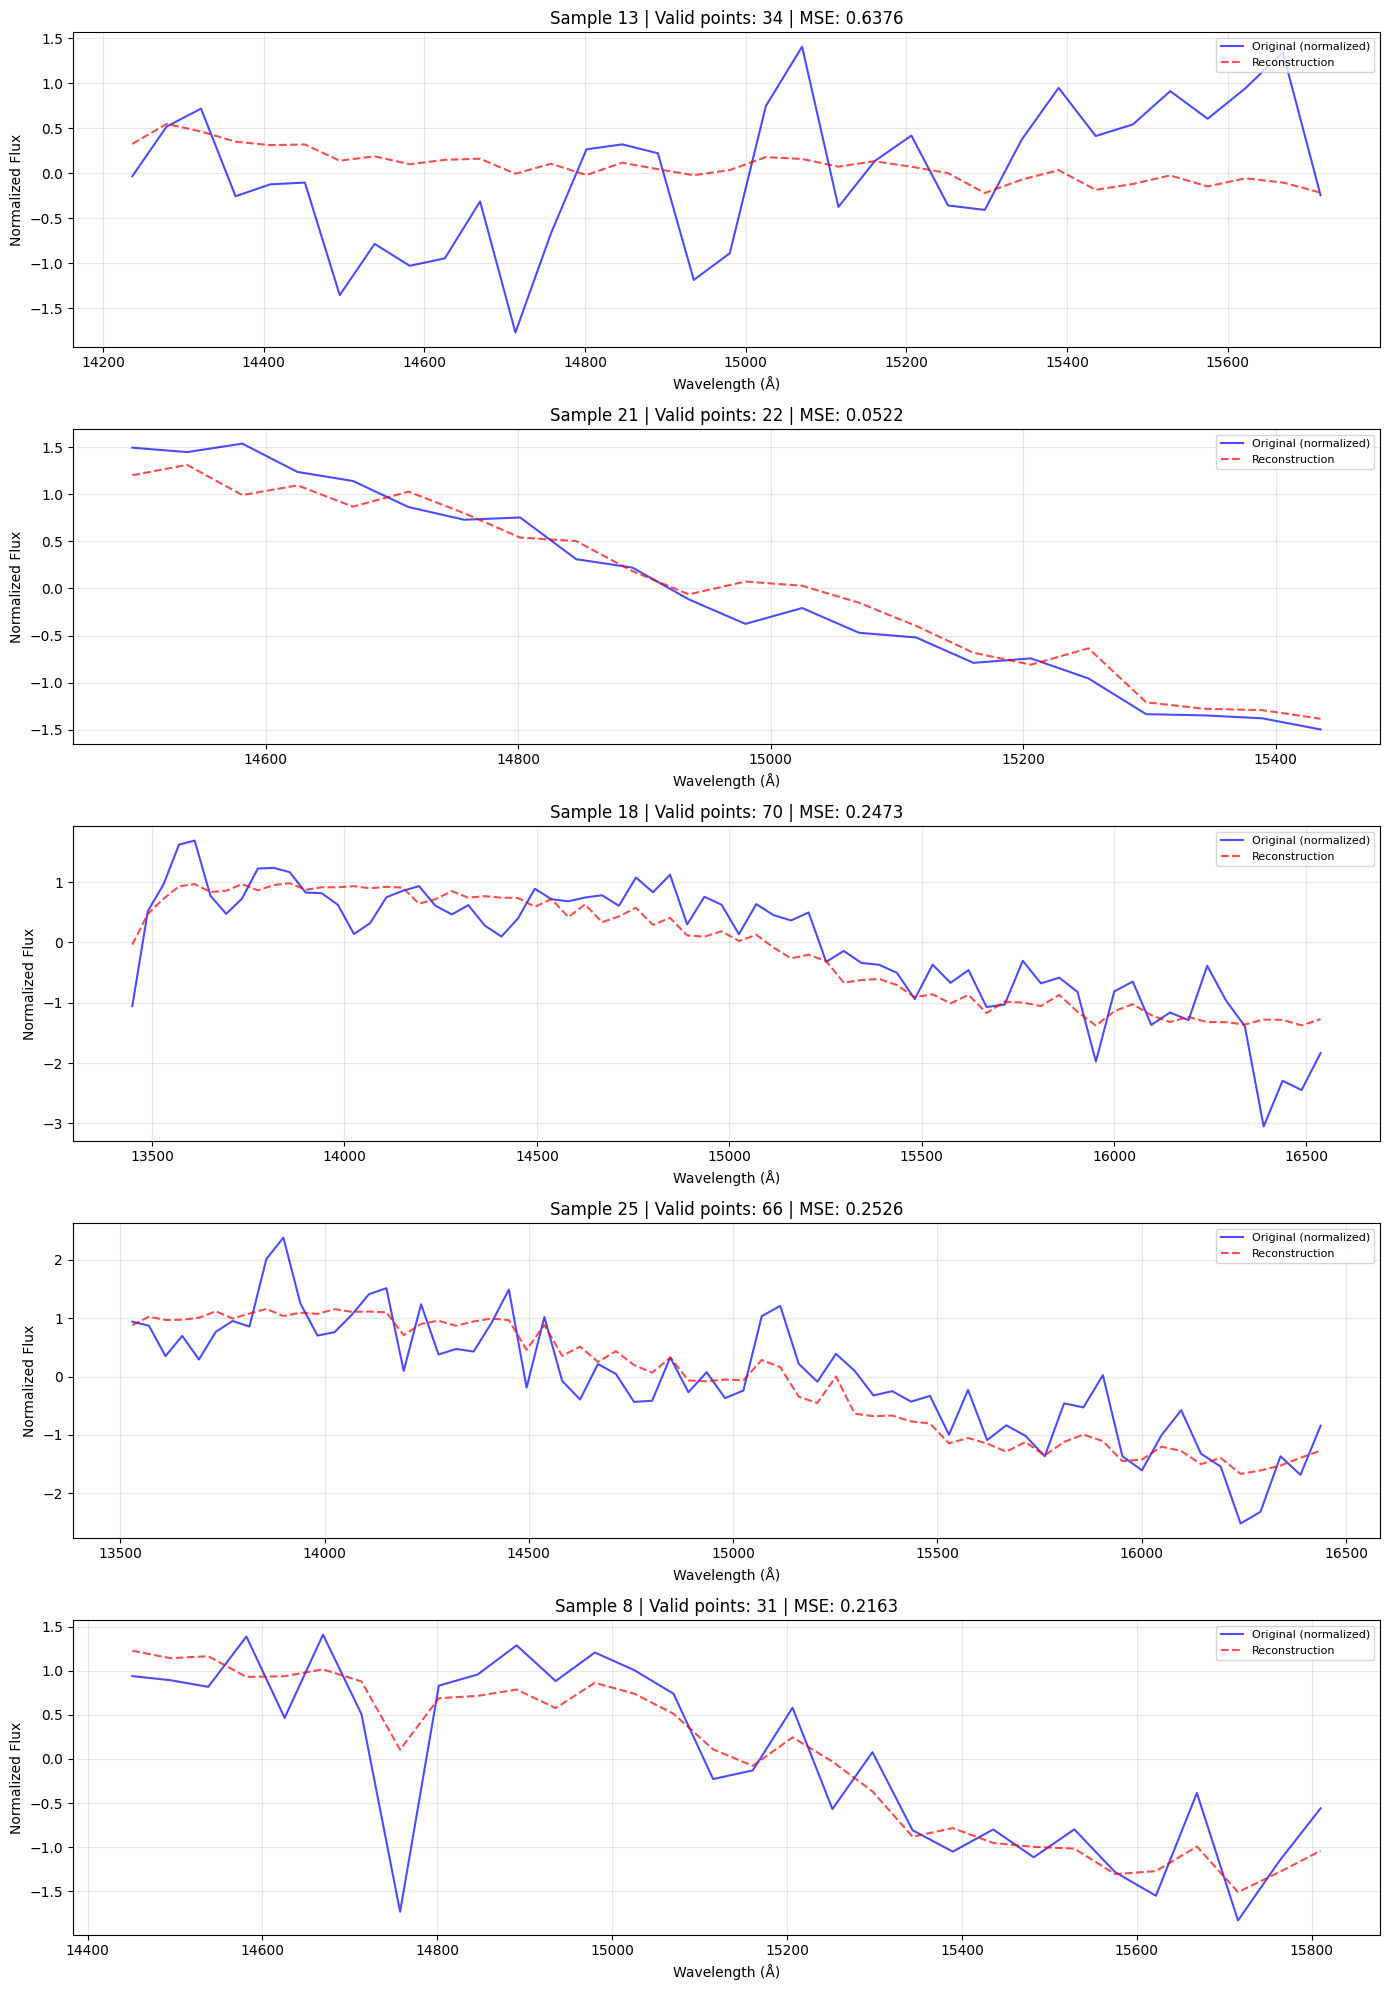

In [ ]:
# Plot first 6 samples from test batch
sample_indices = np.random.randint(0,32,5)
fig = plot_reconstruction_comparison(results, sample_indices)

#check std deviaion.

## Detailed Single Sample View

Zoom in on a single sample to see the reconstruction quality in detail.

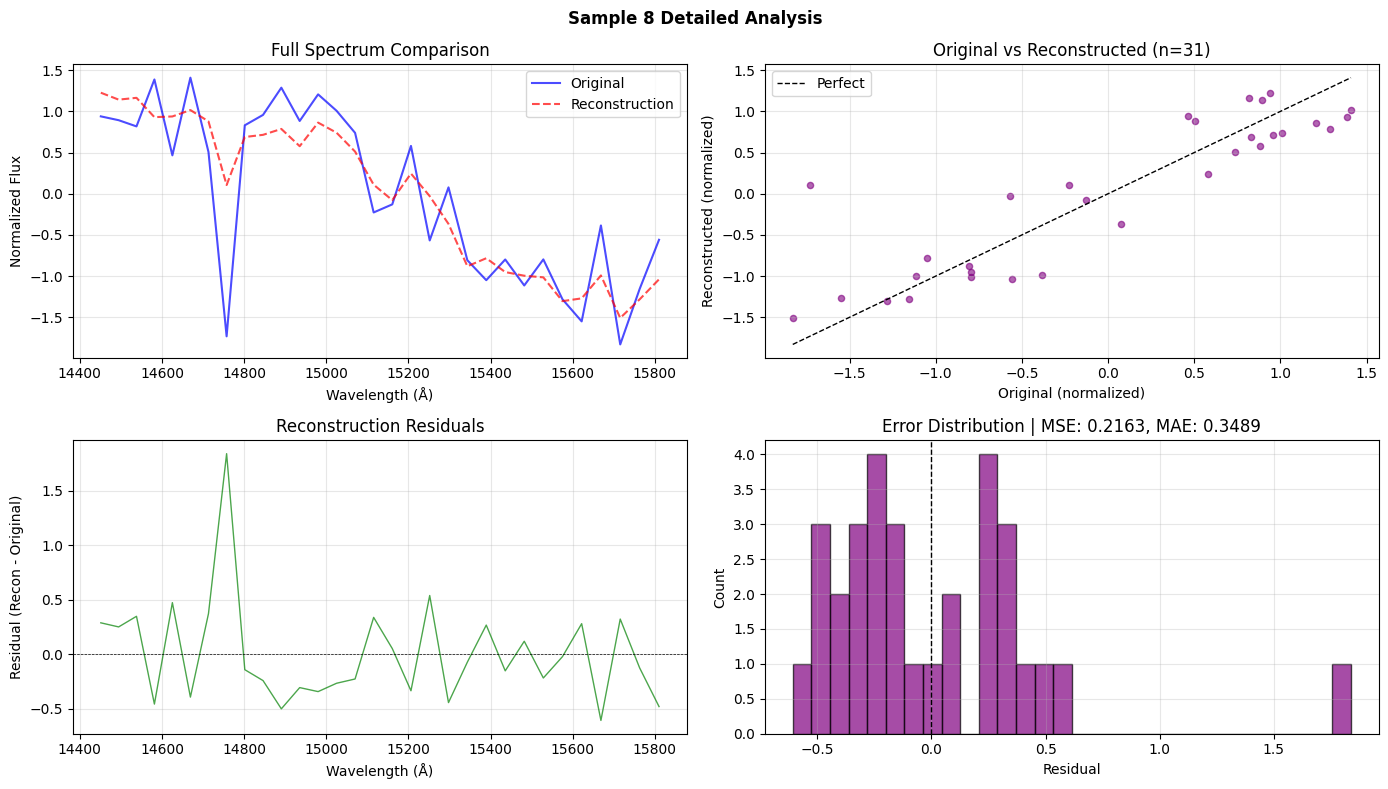

In [ ]:
def plot_detailed_reconstruction(results, sample_idx, figsize=(14, 8)):
    """Plot detailed reconstruction analysis for a single sample."""
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    wavelength = results["wavelength"][sample_idx]
    original = results["original_norm"][sample_idx]
    reconstruction = results["reconstruction"][sample_idx]
    valid_mask = results["valid_mask"][sample_idx].astype(bool)
    
    # Get valid positions
    wl_valid = wavelength[valid_mask]
    orig_valid = original[valid_mask]
    recon_valid = reconstruction[valid_mask]
    
    # Sort by wavelength
    sort_idx = np.argsort(wl_valid)
    wl_sorted = wl_valid[sort_idx]
    orig_sorted = orig_valid[sort_idx]
    recon_sorted = recon_valid[sort_idx]
    
    # 1. Full spectrum comparison
    ax1 = axes[0, 0]
    ax1.plot(wl_sorted, orig_sorted, 'b-', alpha=0.7, linewidth=1.5, label='Original')
    ax1.plot(wl_sorted, recon_sorted, 'r--', alpha=0.7, linewidth=1.5, label='Reconstruction')
    ax1.set_xlabel('Wavelength (Å)')
    ax1.set_ylabel('Normalized Flux')
    ax1.set_title('Full Spectrum Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Original vs Reconstructed scatter
    ax2 = axes[0, 1]
    ax2.scatter(orig_sorted, recon_sorted, c='purple', s=20, alpha=0.6)
    
    # Perfect reconstruction line
    lim_min = min(orig_sorted.min(), recon_sorted.min())
    lim_max = max(orig_sorted.max(), recon_sorted.max())
    ax2.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1, label='Perfect')
    
    ax2.set_xlabel('Original (normalized)')
    ax2.set_ylabel('Reconstructed (normalized)')
    ax2.set_title(f'Original vs Reconstructed (n={len(orig_sorted)})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Residuals (reconstruction error)
    ax3 = axes[1, 0]
    residuals = recon_sorted - orig_sorted
    ax3.plot(wl_sorted, residuals, 'g-', alpha=0.7, linewidth=1)
    ax3.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Residual (Recon - Original)')
    ax3.set_title('Reconstruction Residuals')
    ax3.grid(True, alpha=0.3)
    
    # 4. Error histogram
    ax4 = axes[1, 1]
    ax4.hist(residuals, bins=30, alpha=0.7, color='purple', edgecolor='black')
    mse = np.mean(residuals ** 2)
    mae = np.mean(np.abs(residuals))
    ax4.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax4.set_title(f'Error Distribution | MSE: {mse:.4f}, MAE: {mae:.4f}')
    ax4.set_xlabel('Residual')
    ax4.set_ylabel('Count')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Sample {sample_idx} Detailed Analysis', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

# Show detailed view for sample 0
fig = plot_detailed_reconstruction(results, sample_idx=8)

## Batch-level Reconstruction Statistics

Compute reconstruction metrics across the entire batch.

In [ ]:
def compute_batch_metrics(results):
    """Compute reconstruction metrics across the batch."""
    B = results["original_norm"].shape[0]
    
    all_mse = []
    all_mae = []
    
    for i in range(B):
        valid_mask = results["valid_mask"][i].astype(bool)
        
        orig = results["original_norm"][i][valid_mask]
        recon = results["reconstruction"][i][valid_mask]
        
        if len(orig) > 0:
            mse = np.mean((orig - recon) ** 2)
            mae = np.mean(np.abs(orig - recon))
            all_mse.append(mse)
            all_mae.append(mae)
    
    return {
        "mse_mean": np.mean(all_mse),
        "mse_std": np.std(all_mse),
        "mae_mean": np.mean(all_mae),
        "mae_std": np.std(all_mae),
        "per_sample_mse": all_mse,
    }

# Compute metrics
metrics = compute_batch_metrics(results)

print("=" * 50)
print("Reconstruction Metrics (Test Batch)")
print("=" * 50)
print(f"\nAll Valid Positions:")
print(f"  MSE: {metrics['mse_mean']:.4f} ± {metrics['mse_std']:.4f}")
print(f"  MAE: {metrics['mae_mean']:.4f} ± {metrics['mae_std']:.4f}")

Reconstruction Metrics (Test Batch)

All Valid Positions:
  MSE: 0.4518 ± 0.3455
  MAE: 0.4874 ± 0.2022


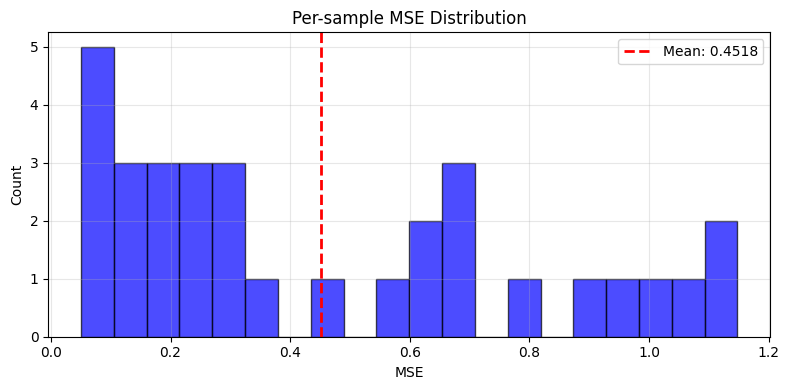

In [ ]:
# Plot per-sample MSE distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(metrics["per_sample_mse"], bins=20, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(x=metrics["mse_mean"], color='red', linestyle='--', linewidth=2, label=f'Mean: {metrics["mse_mean"]:.4f}')
ax.set_xlabel('MSE')
ax.set_ylabel('Count')
ax.set_title('Per-sample MSE Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate on Multiple Batches

Run reconstruction on multiple batches to get more robust statistics.

In [ ]:
# Evaluate on multiple batches for more robust statistics
num_batches = 10
all_mse = []

test_iter = iter(test_loader)
for batch_idx in range(num_batches):
    try:
        batch = next(test_iter)
    except StopIteration:
        break
    
    results = reconstruct_batch(model, batch)
    metrics = compute_batch_metrics(results)
    all_mse.extend(metrics["per_sample_mse"])

print(f"Evaluated on {len(all_mse)} samples from {batch_idx + 1} batches")
print(f"\nOverall Reconstruction Quality:")
print(f"  MSE: {np.mean(all_mse):.4f} ± {np.std(all_mse):.4f}")

Evaluated on 320 samples from 10 batches

Overall Reconstruction Quality:
  MSE: 0.4857 ± 0.3380


## Random Sample Gallery

Display a grid of random test samples with their reconstructions.

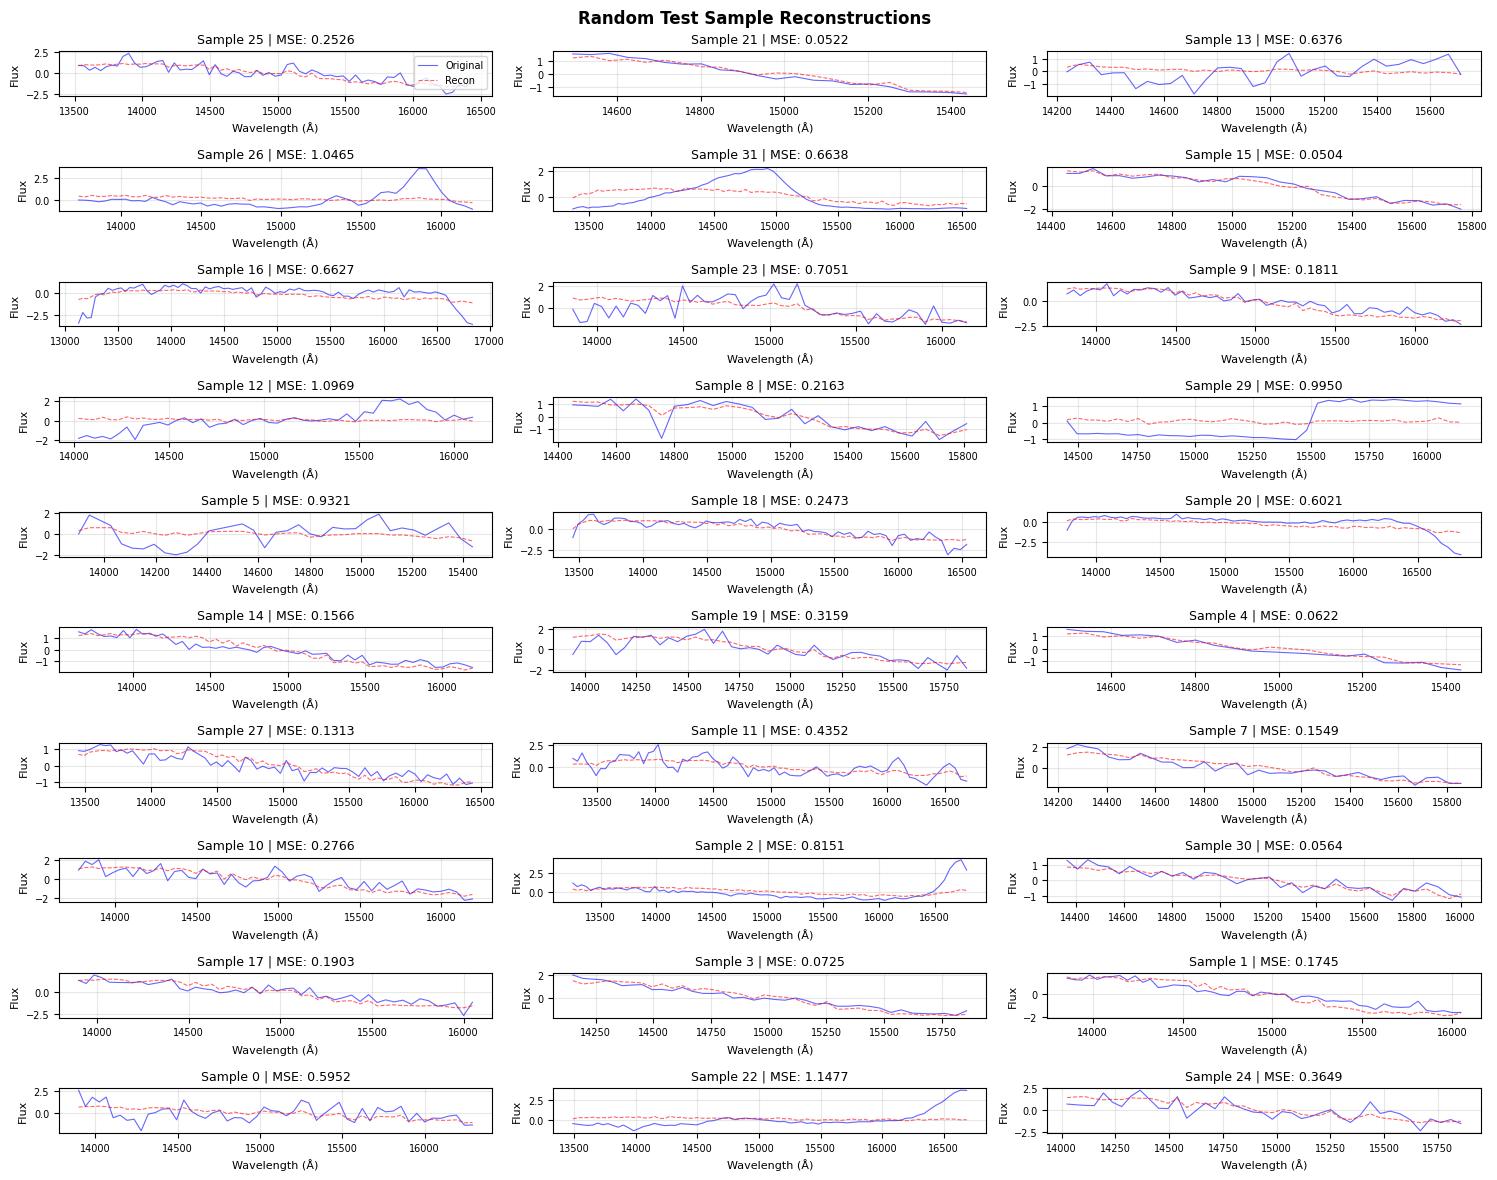

In [ ]:
def plot_sample_gallery(results, n_samples=9, figsize=(15, 12)):
    """Plot a gallery of reconstruction comparisons."""
    n_cols = 3
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    # Randomly select samples
    batch_size = results["original"].shape[0]
    sample_indices = np.random.choice(batch_size, size=min(n_samples, batch_size), replace=False)
    
    for ax_idx, sample_idx in enumerate(sample_indices):
        ax = axes[ax_idx]
        
        wavelength = results["wavelength"][sample_idx]
        original = results["original_norm"][sample_idx]
        reconstruction = results["reconstruction"][sample_idx]
        valid_mask = results["valid_mask"][sample_idx].astype(bool)
        
        # Get valid positions
        wl_valid = wavelength[valid_mask]
        orig_valid = original[valid_mask]
        recon_valid = reconstruction[valid_mask]
        
        # Sort by wavelength
        sort_idx = np.argsort(wl_valid)
        wl_sorted = wl_valid[sort_idx]
        orig_sorted = orig_valid[sort_idx]
        recon_sorted = recon_valid[sort_idx]
        
        # Plot
        ax.plot(wl_sorted, orig_sorted, 'b-', alpha=0.6, linewidth=0.8, label='Original')
        ax.plot(wl_sorted, recon_sorted, 'r--', alpha=0.6, linewidth=0.8, label='Recon')
        
        # Compute MSE
        mse = np.mean((orig_sorted - recon_sorted) ** 2)
        
        ax.set_title(f'Sample {sample_idx} | MSE: {mse:.4f}', fontsize=9)
        ax.set_xlabel('Wavelength (Å)', fontsize=8)
        ax.set_ylabel('Flux', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        
        if ax_idx == 0:
            ax.legend(fontsize=7, loc='upper right')
    
    # Hide unused axes
    for ax_idx in range(len(sample_indices), len(axes)):
        axes[ax_idx].set_visible(False)
    
    plt.suptitle('Random Test Sample Reconstructions', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

# Get a new batch and plot gallery
test_batch = next(iter(test_loader))
results = reconstruct_batch(model, test_batch)
fig = plot_sample_gallery(results, n_samples=30)

## Summary

This notebook benchmarks the MA-SpecFormer model's reconstruction ability (autoencoder-style):

1. **Input**: Complete spectrum with only invalid positions masked
2. **Output**: Reconstructed spectrum at all valid positions
3. **Metric**: MSE between original and reconstructed normalized flux

Key observations:
- Model learns to reconstruct spectral features from the transformer encoding
- Lower MSE indicates better representation quality
- This validates the self-supervised pre-training objective